In [1]:
import pandas as pd
import scipy.stats as stats

In [2]:
data= pd.read_csv('Ordenes_productos_C1_M2.csv', sep=';',encoding='latin-1')

In [3]:
#visualizar los primeros registros
data.head(5)

,orden_id,order_item_id,producto_id,vendedor_id,fecha_envio_limite,precio,valor_flete,codigo_postal_vendedor,ciudad_vendedor,departamento_vendedor,nombre_categoria_producto,longitud_nombre_producto,longitud_descripcion_producto,cantidad_fotos_producto,peso_g_producto,longitud_cm_producto,altura_cm_producto,ancho_cm_producto
0,107500PO59A,A,PO59,VE5389,07/04/2018 18:12,271.86,30.72,52435,Mallama,Nariño,Productos ecoamigables,6,7,27,2486,17,11,14
1,37493PS22B,B,PS22,VE1558,20/10/2017 09:07,115.73,4.68,52203,Colon,Nariño,Carnicería,10,31,20,256,43,2,21
2,28050PK20B,B,PK20,VE9159,17/08/2017 08:15,432.99,82.70,66001,Pereira,Risaralda,Deportes,25,5,4,5270,9,27,29
3,52187PA10A,A,PA10,VE3159,23/09/2017 23:27,108.38,35.39,52435,Mallama,Nariño,Electrodomésticos,10,1,6,734,46,48,22
4,84639PR12A,A,PR12,VE5090,07/01/2018 11:50,51.50,11.10,73001,Ibague,Tolima,Frutas y verduras,23,16,35,884,45,26,18


In [4]:
#buscar la categoría top de productos
categoria_top=data.groupby('nombre_categoria_producto').count().reset_index()[['nombre_categoria_producto','producto_id']].sort_values(by=['producto_id'], ascending=False)
categoria_top_lista=categoria_top.head(1)['nombre_categoria_producto']
categoria_top.head(1)

,nombre_categoria_producto,producto_id
19,Tecnología,543


In [5]:
# Encontrar los departamentos top 5
departamento_top=data.groupby('departamento_vendedor').count().reset_index()[['departamento_vendedor','producto_id']].sort_values(by=['producto_id'], ascending=False)
departamento_top_lista=departamento_top.head()['departamento_vendedor'].to_list()
departamento_top.head()

,departamento_vendedor,producto_id
21,Nariño,3648
20,Meta,1258
22,Norte de santander,473
25,Risaralda,405
7,Caldas,378


In [6]:
#filtrar por los departamentos top
data_top=data[data['nombre_categoria_producto'].isin(categoria_top_lista) & data['departamento_vendedor'].isin(departamento_top_lista)]
data_top[['precio','departamento_vendedor','nombre_categoria_producto']].head()

,precio,departamento_vendedor,nombre_categoria_producto
23,42.16,Nariño,Tecnología
30,169.49,Nariño,Tecnología
52,55.03,Norte de santander,Tecnología
77,27.17,Norte de santander,Tecnología
79,166.54,Nariño,Tecnología


In [7]:
# Variables de interés
data_muestra=data_top[['precio','departamento_vendedor']]
tamano_grupos = data_muestra.groupby('departamento_vendedor').count().reset_index()
tamano_grupos

,departamento_vendedor,precio
0,Caldas,21
1,Meta,63
2,Nariño,196
3,Norte de santander,27
4,Risaralda,19


<Axes: xlabel='departamento_vendedor'>

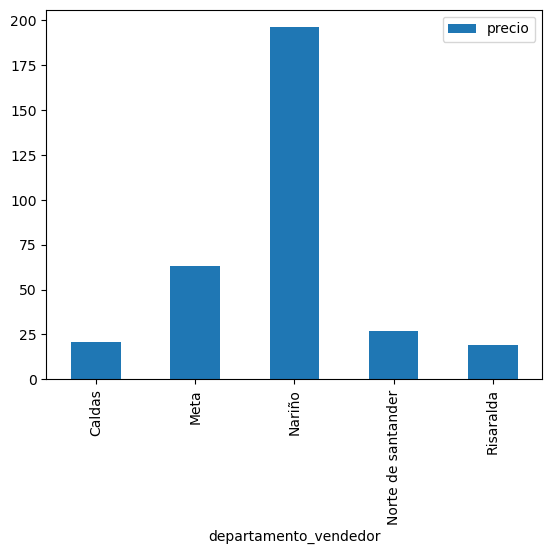

In [8]:
tamano_grupos.plot(kind='bar',x='departamento_vendedor',y='precio')

In [9]:
# varianza de los grupos
varianza_grupos = data_muestra.groupby('departamento_vendedor').std()
varianza_grupos

,precio
departamento_vendedor,
Caldas,176.368851
Meta,120.927717
Nariño,128.275393
Norte de santander,84.396308
Risaralda,160.746558


In [10]:
# Crear la estructura de tabla ANOVA 
data = [['SSA', '', '', '', '', ''], ['SSE', '', '', '', '', ''], ['Total', '', '', '', '', '']] 
anova_tabla = pd.DataFrame(data, columns = ['Fuente de variación', 'SS', 'gdl', 'MS', 'F', 'P-valor']) 
anova_tabla.set_index('Fuente de variación', inplace = True)
anova_tabla

,SS,gdl,MS,F,P-valor
Fuente de variación,,,,,
SSA,,,,,
SSE,,,,,
Total,,,,,


In [14]:
# Calcular la SSA y actualizamos la tabla
promedio_precio = data_muestra['precio'].mean()
SSA = data_muestra.groupby('departamento_vendedor').count() * (data_muestra.groupby('departamento_vendedor').mean() - promedio_precio)**2
anova_tabla.at['SSA', 'SS'] = SSA['precio'].sum()
float(anova_tabla.at['SSA', 'SS'])

118419.6381464703

In [16]:
# Calculas la SSE y actualizar en la tabla
SSE = (data_muestra.groupby('departamento_vendedor').count() - 1) * data_muestra.groupby('departamento_vendedor').std()**2
anova_tabla.at['SSE', 'SS'] = SSE['precio'].sum()
float(anova_tabla.at['SSE', 'SS'])

5387720.999827761

In [17]:
# Calcular SST y actualizar en la tabla
SST = SSA['precio'].sum() + SSE['precio'].sum()
anova_tabla.at['Total', 'SS']= SST
float(anova_tabla.at['Total', 'SS'])

5506140.6379742315

In [18]:
# Calcular los grados de libertas
anova_tabla['gdl']['SSA'] = data_muestra['departamento_vendedor'].nunique() - 1
anova_tabla['gdl']['SSE'] = data_muestra.shape[0] - data_muestra['departamento_vendedor'].nunique()
anova_tabla['gdl']['Total'] = data_muestra.shape[0] - 1

C:\Users\josep\AppData\Local\Temp\ipykernel_6684\1395287397.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  anova_tabla['gdl']['SSA'] = data_muestra['departamento_vendedor'].nunique() - 1
C:\Users\josep\AppData\Local\Temp\ipykernel_6684\

In [19]:
anova_tabla['gdl']['SSA']

4

In [20]:
anova_tabla['gdl']['SSE']

321

In [21]:
anova_tabla['gdl']['Total']

325

In [22]:
# Calcular MS
anova_tabla['MS'] = anova_tabla['SS'] / anova_tabla['gdl']
anova_tabla['MS']

Fuente de variación
SSA      29604.909537
SSE       16784.17757
Total    16941.971194
Name: MS, dtype: object

In [24]:
# Calcular F 
F = anova_tabla['MS']['SSA'] / anova_tabla['MS']['SSE']
anova_tabla.at['SSA','F'] = F
float(F)

1.7638582178917668

In [26]:
# Calcular p-valor
anova_tabla.at['SSA','P-valor'] = 1 - stats.f.cdf(F, anova_tabla.at['SSA','gdl'], anova_tabla.at['SSE','gdl'])
float(anova_tabla.at['SSA','P-valor'])

0.13585222308475475

In [27]:
# Visualizar tabla ANOVA
anova_tabla

,SS,gdl,MS,F,P-valor
Fuente de variación,,,,,
SSA,118419.638146,4,29604.909537,1.763858,0.135852
SSE,5387720.999828,321,16784.17757,,
Total,5506140.637974,325,16941.971194,,


In [29]:
float(anova_tabla.at['SSA','P-valor'])

0.13585222308475475

In [31]:
# Evaluar la hipótesis con un nivel de confianza del 95% y significancia del 5%
alpha=0.05 

print("H0:los promedios de las muestras son iguales")
print("H1:al menos uno de los promedios de las muestras es diferente")

print("Usar el P-valor para decidir sobre la hipótesis")
if anova_tabla.at['SSA','P-valor'] <= alpha:
    conclusion = "Se rechaza hipótesis nula "
else:
    conclusion = "No se rechaza hipótesis nula "
print(conclusion)
print("Valor F es:", anova_tabla['F']['SSA'], " y el P-valor es:", anova_tabla['P-valor']['SSA'])    


H0:los promedios de las muestras son iguales
H1:al menos uno de los promedios de las muestras es diferente
Usar el P-valor para decidir sobre la hipótesis
No se rechaza hipótesis nula 
Valor F es: 1.7638582178917668  y el P-valor es: 0.13585222308475475
